# Treemap

A treemap shows how a total divides into parts, and how those parts divide again: every tile is a rectangle whose area is its value, so the reader sees at a glance which parts dominate, and inside which groups. This guide shows how to create treemaps with the [datachart.charts.Treemap](../../../references/charts/treemap/#datachart.charts.Treemap) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-treemap), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import Treemap

## Basics

The examples in this guide share one dataset: the world's population in 2024 by continent and country, in millions, from the United Nations *World Population Prospects 2024* (approximate mid-year estimates, rounded). The data lives in a hidden cell. `WORLD` maps each continent (the UN regions, so the Americas split into Northern America and Latin America) to its most populous countries and an "Other" record that makes the continent whole, and `world` turns it into treemap records. Population is a textbook part-of-whole story: the world splits into continents, each continent into countries, and a treemap shows both splits at once. It answers questions a table hides: how much of humanity lives in two countries, and how small Europe has become next to Africa.

In [2]:
# World population in 2024 by continent and country, millions (UN World
# Population Prospects 2024, rounded); "Other" completes each continent
WORLD = {
    "Asia": [
        ("India", 1451), ("China", 1419), ("Indonesia", 283), ("Pakistan", 251),
        ("Bangladesh", 174), ("Japan", 124), ("Philippines", 116), ("Vietnam", 101),
        ("Other", 910),
    ],
    "Africa": [
        ("Nigeria", 233), ("Ethiopia", 130), ("Egypt", 116), ("DR Congo", 109),
        ("Tanzania", 69), ("South Africa", 64), ("Kenya", 56), ("Other", 717),
    ],
    "Europe": [
        ("Russia", 144), ("Germany", 84), ("UK", 69), ("France", 66), ("Italy", 59),
        ("Other", 322),
    ],
    "Latin America": [
        ("Brazil", 212), ("Mexico", 131), ("Colombia", 53), ("Argentina", 45),
        ("Other", 225),
    ],
    "Northern America": [("USA", 345), ("Canada", 40)],
    "Oceania": [("Australia", 27), ("Papua New Guinea", 10), ("New Zealand", 5), ("Other", 4)],
}

# one record per continent, its countries as children
world = {
    "data": [
        {"label": continent, "children": [{"label": c, "value": n} for c, n in countries]}
        for continent, countries in WORLD.items()
    ]
}

The data is one dict with a `data` list of records. A record is a dict with a `label` and a `value` above zero; a record that carries `children` is a group, and its children are records of the same shape. A group either omits its `value` or carries the sum of its children; anything else raises a `ValueError`, as does a zero or negative value. The order of the records does not matter: every level is sorted largest first before it is tiled. The first continent and three of its countries:

In [3]:
world["data"][0]["label"], world["data"][0]["children"][:3]

('Asia',
 [{'label': 'India', 'value': 1451},
  {'label': 'China', 'value': 1419},
  {'label': 'Indonesia', 'value': 283}])

**Basic example.** Only the `data` argument is required. Each continent is a box in its own color with a header band, its countries are tiles in a lighter tint inside it, and the largest tile of every level sits top-left. The tiles are squarified in the drawn aspect of the axes, so they stay near square whatever the figure size. A label that does not fit its tile wraps, then shrinks, then is dropped; a group too short for its band goes unlabeled, and the [legend](#legend) is what names it.

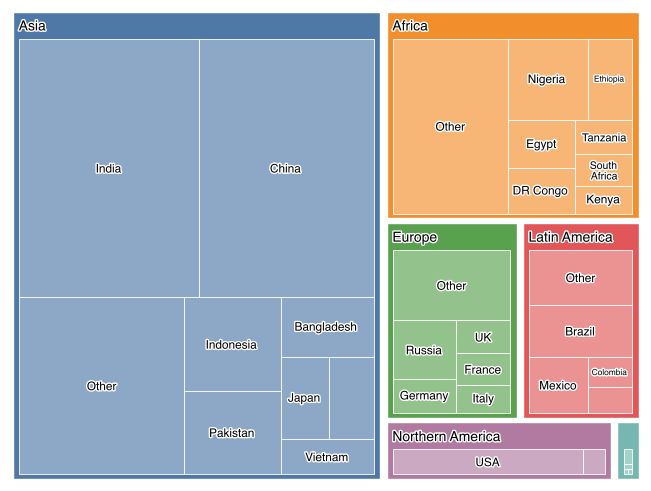

In [4]:
Treemap(
    # add the data to the chart
    data=world
).show()

## Customizing the Treemap

Every customization is either a keyword argument of `Treemap` or a `plot_treemap_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title and figure size](#title-and-figure-size) |
| tile one level without groups               | records without `children`                                              | [Flat data](#flat-data) |
| nest groups inside groups                   | `children` on a child record, up to four levels                         | [Nested groups](#nested-groups) |
| write the values on the tiles               | `show_values`, `value_format`                                           | [Tile values](#tile-values) |
| mute or outline a tile or a group           | `"emphasis"` on the record                                              | [Emphasis](#emphasis) |
| highlight the tiles that match a rule       | `emphasis_rule`                                                         | [Emphasis](#emphasis) |
| name the groups in a legend                 | `show_legend`                                                           | [Legend](#legend) |
| title and place the legend                  | `legend`                                                                | [Legend](#legend) |
| widen the gap around groups                 | `style={"plot_treemap_group_pad": ...}`                               | [Tile style](#tile-style) |
| change the tint of the tiles in a group     | `style={"plot_treemap_level_shade": ...}`                             | [Tile style](#tile-style) |
| change the strokes or the label sizes       | `style={"plot_treemap_edge_width": ..., "plot_treemap_min_fontsize": ...}` | [Tile style](#tile-style) |
| drop the halo behind the labels             | `style={"plot_treemap_label_halo_width": 0}`                          | [Tile style](#tile-style) |
| put a note on the chart                     | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several treemaps side by side          | a list of dicts as `data`, `subtitle`, `max_cols`                       | [Subplots](#subplots) |
| arrange a treemap next to other charts      | `Grid`                                                                  | [Composing treemaps](#composing-treemaps) |
| draw the chart in another look              | `config.set_theme`                                                      | [Themes](#themes) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |

The full list of style attributes is in the [datachart.typings.TreemapStyleAttrs](../../../references/charts/treemap/#datachart.typings.TreemapStyleAttrs) type; the full list of parameters is in the [datachart.charts.Treemap](../../../references/charts/treemap/#datachart.charts.Treemap) reference.

### Title and figure size

A treemap has no axes to label, so the title is the only place that says what the areas measure; `title` sets it, units included. The chart sits in a page column, so its size should match it. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE); the tiles are laid out in the aspect of the figure you choose, so a wide figure and a tall one both keep them near square. `FIG_SIZE.FULL_MEDIUM` fills the width of a page and leaves the forty tiles room for their labels.

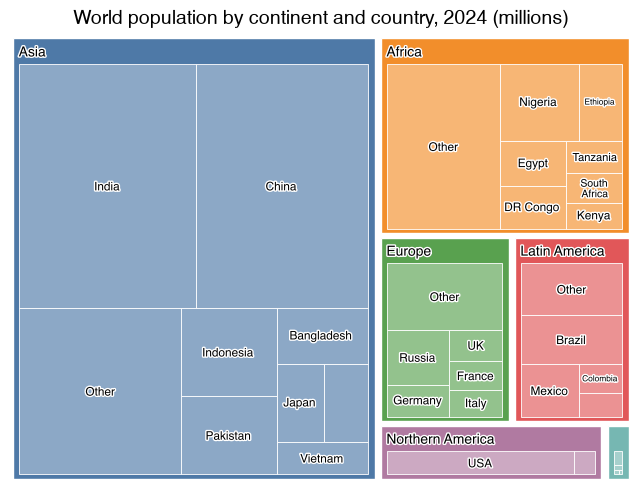

In [5]:
from datachart.constants import FIG_SIZE

Treemap(
    data=world,
    # say what the areas measure
    title="World population by continent and country, 2024 (millions)",
    # room for the small tiles' labels
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Flat data

Sometimes the question stops at the first split: how do the continents compare? Records without `children` are tiles of their own, each in the next palette color, with no bands or borders. The example tiles the continent totals, the top level of the nested chart on its own: Asia alone covers more than half of the drawing.

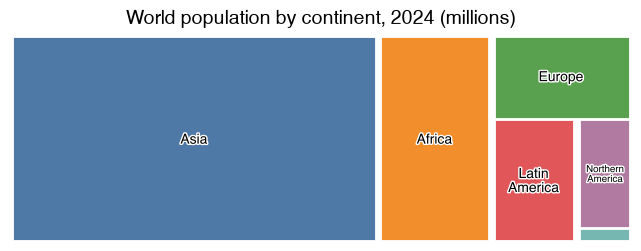

In [6]:
# one record per continent, its total as the value
continents = {
    "data": [
        {"label": continent, "value": sum(n for _, n in countries)}
        for continent, countries in WORLD.items()
    ]
}

Treemap(
    data=continents,
    title="World population by continent, 2024 (millions)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Nested groups

Real hierarchies are often deeper than two levels: regions inside continents, folders inside folders. A child record may carry `children` of its own, and every level follows the rules of the top one: a group is a box in its color with a header band, its children one tint lighter inside it, the largest top-left. Every group insets its children by `plot_treemap_group_pad`, so a nested box sits visibly inside its parent's color. A nested group whose box is short draws its band in a smaller font, and one too short even for that draws its border only; the [legend](#legend) names the top-level groups alone.

The example adds a level above the continents, the landmasses: Afro-Eurasia, the Americas, and Oceania. The records are the same as before, grouped once more, and the picture answers a new question: how much of humanity lives on one landmass.

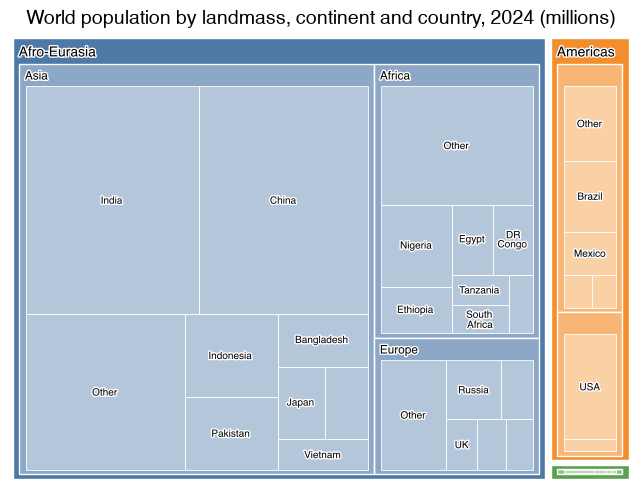

In [7]:
LANDMASSES = {
    "Afro-Eurasia": ["Asia", "Africa", "Europe"],
    "Americas": ["Latin America", "Northern America"],
    "Oceania": ["Oceania"],
}
by_continent = {record["label"]: record for record in world["data"]}

# three levels: landmass, continent, country
landmasses = {
    "data": [
        {"label": land, "children": [by_continent[c] for c in names]}
        for land, names in LANDMASSES.items()
    ]
}

Treemap(
    data=landmasses,
    title="World population by landmass, continent and country, 2024 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

!!! note "Four levels of nesting"
    A treemap nests its records four levels deep: the `data` list is the first level, and a record at the fourth cannot carry `children` of its own. The cap is a readability limit: every level takes a header band and a lighter tint from its parent, and at the usual figure sizes a fifth level has no room left for its labels. For a deeper hierarchy, fold the lowest levels into "Other" records, or draw a subtree as its own treemap with [subplots](#subplots). [Example 1](#example-1-where-did-the-disk-space-go-four-levels-values-and-a-highlight) nests four levels.

### Tile values

Area shows the proportions, but not the numbers behind them: is India bigger than China, and by how much? `show_values` writes each tile's value under its label, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string. Values follow the labels' fitting rules, and when a tile has room for its label but not both, the value is dropped first. The format below appends the unit, and the two largest tiles settle the question: India, 1,451 million, just ahead of China.

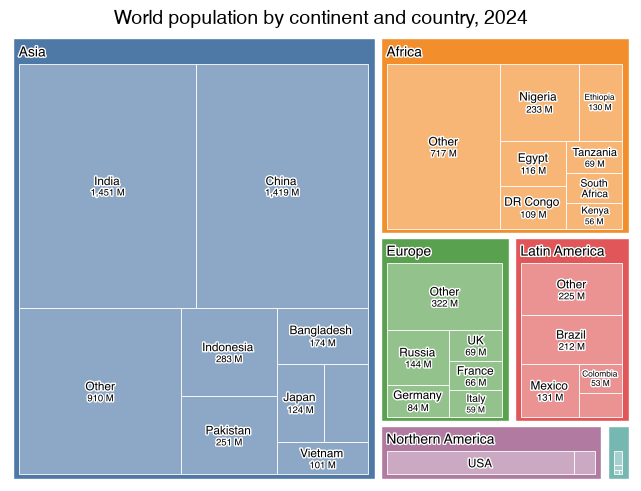

In [8]:
Treemap(
    data=world,
    # write the population on the tiles, with its unit
    show_values=True,
    value_format="{x:,} M",
    title="World population by continent and country, 2024",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

When the share matters more than the count, turn the values into fractions of the total and format them with `VALUE_FORMAT.PERCENT`, which multiplies by 100 and keeps one decimal. The tiling is unchanged, since only the proportions count, and the two largest tiles now read as more than a third of humanity:

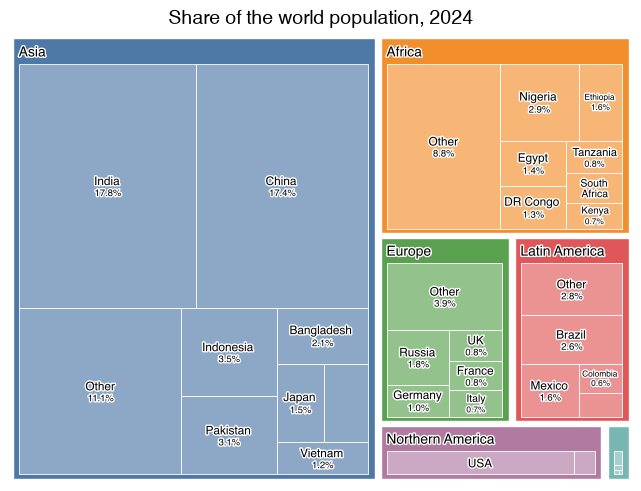

In [9]:
from datachart.constants import VALUE_FORMAT

total = sum(record["value"] for record in continents["data"])
# the same records, each value as a share of the world
shares = {
    "data": [
        {"label": continent, "children": [{"label": c, "value": n / total} for c, n in countries]}
        for continent, countries in WORLD.items()
    ]
}

Treemap(
    data=shares,
    show_values=True,
    # a fraction printed as a percent with one decimal
    value_format=VALUE_FORMAT.PERCENT,
    title="Share of the world population, 2024",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

A treemap of forty countries makes no point until one is picked out. Every record takes an `emphasis` key with one of the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) roles: `"background"` mutes a tile or a whole group into the theme's muted color, and `"highlight"` strokes its border in the text color. A role applies to the record's whole subtree, and a descendant's own role overrides it, so a highlighted country stays vivid inside a muted continent. Roles are explicit: highlighting one record does not mute the others. The `emphasis` argument of the function itself is not supported (it raises a `ValueError`); pass the roles on the records. The example asks where the fastest-growing populations live: Africa is highlighted, the rest muted, and Pakistan keeps its color inside a muted Asia.

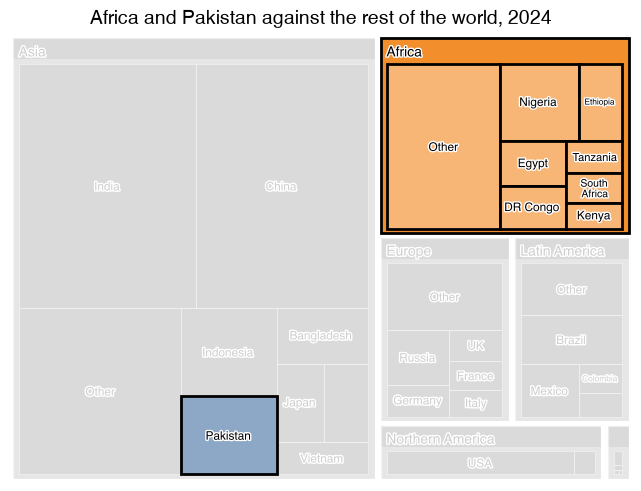

In [10]:
from datachart.constants import EMPHASIS

africa_marked = {
    "data": [
        {
            "label": continent,
            # Africa stands out, every other continent is muted
            "emphasis": EMPHASIS.HIGHLIGHT if continent == "Africa" else EMPHASIS.BACKGROUND,
            "children": [
                # Pakistan's own role wins over muted Asia
                {"label": c, "value": n, **({"emphasis": EMPHASIS.HIGHLIGHT} if c == "Pakistan" else {})}
                for c, n in countries
            ],
        }
        for continent, countries in WORLD.items()
    ]
}

Treemap(
    data=africa_marked,
    title="Africa and Pakistan against the rest of the world, 2024",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

`emphasis_rule` picks the tiles from the data instead of tagging them by hand. It is a one-key dictionary read against each leaf's `value`: `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive); the leaves that match are highlighted and the other leaves muted. A record's own `emphasis` key wins over the rule, and so does a group's for every leaf inside it. The rule below asks which countries pass 200 million. The "Other" records would match too, so they are muted by their own key. The [Highlighting](../../styling/highlighting/) guide covers the rule across every chart.

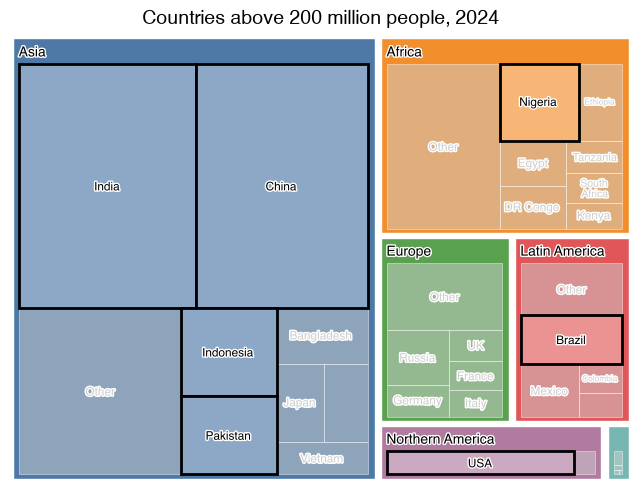

In [11]:
# the "Other" records are not countries: mute them by hand
countries_only = {
    "data": [
        {
            "label": record["label"],
            "children": [
                {**child, "emphasis": EMPHASIS.BACKGROUND} if child["label"] == "Other" else child
                for child in record["children"]
            ],
        }
        for record in world["data"]
    ]
}

Treemap(
    data=countries_only,
    # every country above 200 million
    emphasis_rule={"above": 200},
    title="Countries above 200 million people, 2024",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Legend

A group too short for its header band goes unlabeled: in the charts above, Oceania is a thin strip with no name. `show_legend` lists the top-level records beside the tiles, since the tiles fill the axes, and names every group whatever its size. `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). Below the tiles, in three columns, the legend leaves the full width to the tiling.

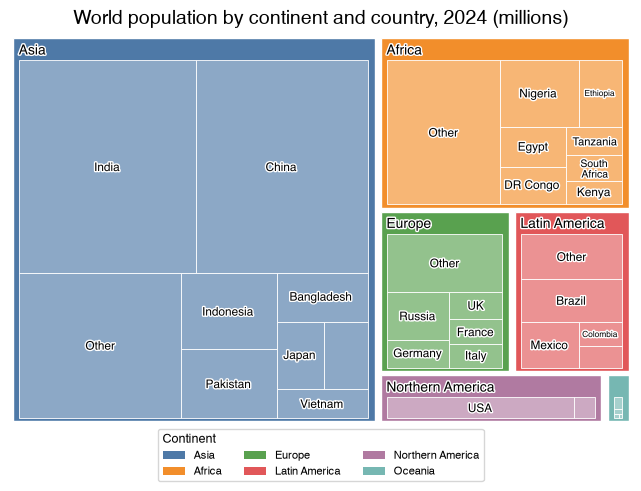

In [12]:
from datachart.constants import LEGEND_LOCATION

Treemap(
    data=world,
    # name every continent, Oceania included
    show_legend=True,
    legend={"title": "Continent", "location": LEGEND_LOCATION.OUTSIDE_BOTTOM, "ncols": 3},
    title="World population by continent and country, 2024 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Tile style

The `style` dictionary sets how the boxes are separated and how the levels are told apart; the attributes are listed in [datachart.typings.TreemapStyleAttrs](../../../references/charts/treemap/#datachart.typings.TreemapStyleAttrs), and any attribute left out keeps the value of the active theme.

- `plot_treemap_group_pad` is the gap between the top-level records and, in the group's color, between a group's border and its children, as a fraction of the drawing.
- Children meet at a stroke only, drawn in `plot_treemap_edge_color` at `plot_treemap_edge_width`; `plot_treemap_group_edge_width` draws the border around a group, and `plot_treemap_highlight_edge_width` the border of a highlighted record.
- `plot_treemap_level_shade` says how much lighter than its parent each level is, from `0` (the group color) to `1` (white).
- Labels shrink by `plot_treemap_level_font_scale` per nesting level and down to `plot_treemap_min_fontsize` before they are dropped; each sits on a halo of `plot_treemap_label_halo_width`, and `0` drops it.

A treemap bound for a slide is read from afar: wider gaps between the continents and countries close to the continent color read as solid blocks, and a smaller minimum font lets a label shrink further before it is dropped.

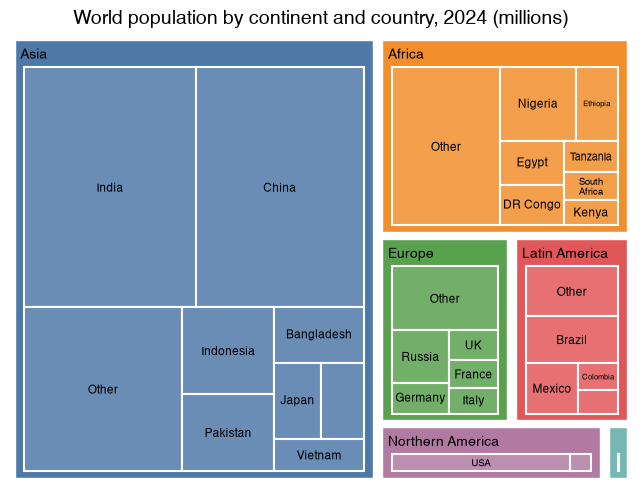

In [13]:
Treemap(
    data=world,
    style={
        # a wider gap around the continents
        "plot_treemap_group_pad": 0.015,
        # the countries close to the continent color
        "plot_treemap_level_shade": 0.15,
        # white strokes between the countries
        "plot_treemap_edge_color": "white",
        "plot_treemap_edge_width": 1.5,
        # keep smaller labels, without a halo
        "plot_treemap_min_fontsize": 5,
        "plot_treemap_label_halo_width": 0,
    },
    title="World population by continent and country, 2024 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Text annotations

Some facts are not a tile: a share, a comparison, a caveat. `texts` places notes on the chart; the tiling spans `0` to `1` in both directions, so `x` and `y` are fractions of the drawing, with `y` running up from the bottom; a `target` would add a connector to a point. The [Text Annotations](../../utility/annotations/) guide covers placement, connectors and boxes. The note computes how much of the world lives in India and China together and sits on the boundary between their tiles.

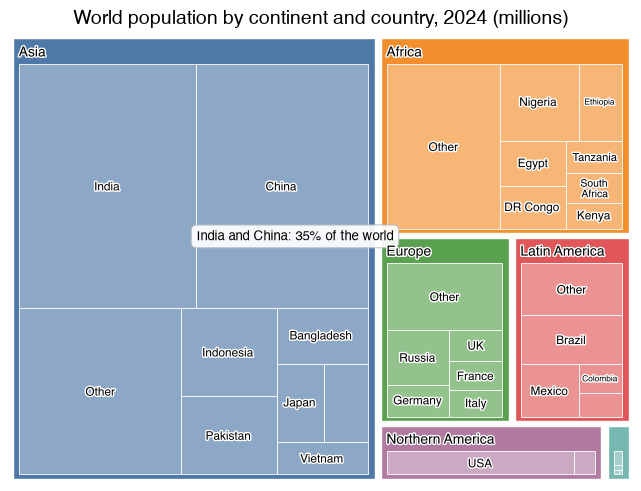

In [14]:
asia = dict(WORLD["Asia"])
two_giants = (asia["India"] + asia["China"]) / total

Treemap(
    data=world,
    texts={
        "text": f"India and China: {two_giants:.0%} of the world",
        # on the boundary of the two largest tiles; y runs from the bottom
        "x": 0.3,
        "y": 0.55,
        "ha": "center",
    },
    title="World population by continent and country, 2024 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Treemaps

### Subplots

A large group squeezes its countries into a corner; drawn alone, its countries get the whole drawing. A list of `{"data": [...]}` dicts draws one treemap per subplot; two treemaps never share axes, so `subplots` is implied. `subtitle` titles each subplot, `title` stays global, and `max_cols` limits the subplots per row. Each subplot fills its own area, so the areas compare within a subplot, not across them: Asia and Africa below look the same size although Asia has three times the people.

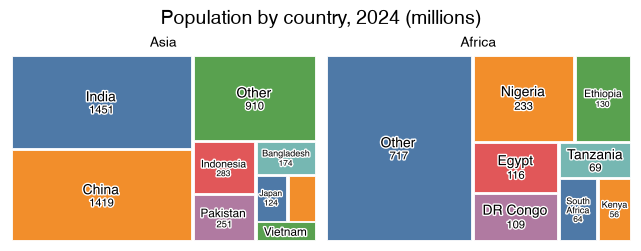

In [15]:
Treemap(
    # one treemap per continent
    data=[{"data": [{"label": c, "value": n} for c, n in WORLD[name]]} for name in ("Asia", "Africa")],
    subtitle=["Asia", "Africa"],
    max_cols=2,
    show_values=True,
    title="Population by country, 2024 (millions)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Composing treemaps

A treemap shows shares; a second chart can put the counts beside them. A treemap owns its axes: its tiling is not a coordinate space another chart can share, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a treemap figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it next to other figures as an ordinary cell, and the tiles are laid out again in the cell's own aspect; the [Grid](../../utility/grid/) guide covers the layout options. The example pairs the continents with a horizontal [BarChart](../barchart/) of the same totals, which reads the exact ranking a treemap only hints at.

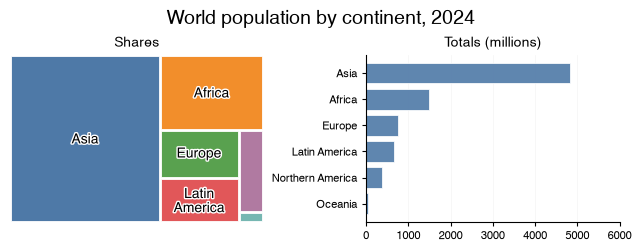

In [16]:
from datachart.charts import BarChart
from datachart.constants import ORIENTATION, SHOW_GRID, SORT
from datachart.utils import Grid

tiles = Treemap(data=continents, title="Shares")
totals = BarChart(
    data=[{"label": r["label"], "y": r["value"]} for r in continents["data"]],
    title="Totals (millions)",
    orientation=ORIENTATION.HORIZONTAL,
    # largest at the top
    sort=SORT.ASCENDING,
    show_grid=SHOW_GRID.X,
    xmin=0,
)
Grid([[tiles, totals]], title="World population by continent, 2024", figsize=FIG_SIZE.FULL_SHORT).show()

## Additional Features

### Themes

A theme sets the palette, the strokes and the fonts of every chart at once; see the [Theme Gallery](../../styling/theme-gallery/) for the whole suite under each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [THEME](../../../references/constants/#datachart.constants.THEME) constant, and reset the configuration afterwards so the following charts draw in the default again. A treemap destined for a black-and-white print needs its groups told apart without color: `THEME.QUILL` etches each top-level group in its own hatch pattern, and its `plot_treemap_etch_density` style attribute sets how densely each nesting level repeats it.

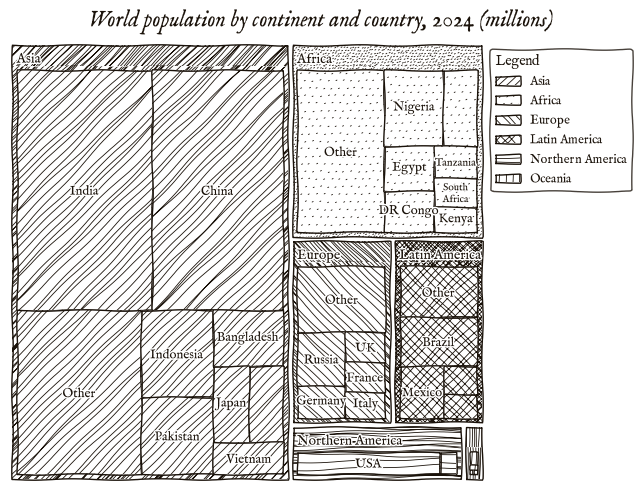

In [17]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.QUILL)
figure = Treemap(
    data=world,
    show_legend=True,
    title="World population by continent and country, 2024 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Real-World Examples

The examples below put the features above to work, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Where Did the Disk Space Go? (Four Levels, Values, and a Highlight)

A full disk raises one question: which folder to clean up. `HOME` is an illustrative home folder four levels deep, sized in gigabytes the way a disk-usage tool reports it: a dict is a folder, a number a size. A small recursive helper turns it into records, `show_values` writes the sizes with their unit, and the one folder worth cleaning, a thesis's raw data, is highlighted. The treemap shows what a folder listing hides: the largest sub-folder sits three levels down, inside Projects, and it outweighs every other sub-folder on the disk.

In [18]:
# an illustrative home folder: a dict is a folder, a number a size in GB
HOME = {
    "Projects": {
        "thesis": {"raw data": {"2024": 48, "2025": 71}, "figures": 18, "chapters": 4},
        "datachart": {".venv": 22, "docs": 14, "src": 6, "test": 3},
        "scratch": {"notes": 3, "tmp": 6},
    },
    "Media": {
        "Photos": {"2024": 38, "2025": 52},
        "Videos": 47,
        "Music": 12,
    },
    "Library": {"Caches": 28, "Mail": 5, "Fonts": 2},
    "Downloads": 24,
    "Desktop": 5,
}

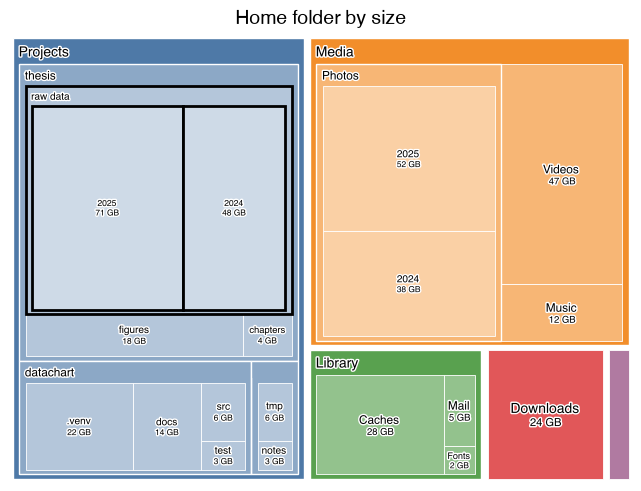

In [19]:
def records(tree, flagged="raw data"):
    # a number is a tile, a dict a group; the flagged folder is highlighted
    return [
        {
            "label": name,
            **({"value": size} if not isinstance(size, dict) else {"children": records(size, flagged)}),
            **({"emphasis": EMPHASIS.HIGHLIGHT} if name == flagged else {}),
        }
        for name, size in tree.items()
    ]


Treemap(
    data={"data": records(HOME)},
    show_values=True,
    value_format="{x} GB",
    title="Home folder by size",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Which Costs Can the Team Change? (Muted Fixed Costs, Thousands, and a Legend)

A budget review asks where money can be saved, and fixed costs are not the answer. `BUDGET` is an illustrative yearly budget of a software company, split by department and then by line, in thousands of EUR. The fixed costs (rent and insurance) are context, not a lever, so their group is muted; `VALUE_FORMAT.THOUSANDS` groups the digits; and the legend, placed below, names every department, including the ones too small for a band, while the muted fixed costs stay out of it like any background mark. Engineering salaries and the cloud bill are where a saving would show.

In [20]:
# an illustrative yearly budget, thousands of EUR
BUDGET = {
    "Engineering": [("Salaries", 1450), ("Cloud", 380), ("Tooling", 90), ("Training", 45)],
    "Sales": [("Salaries", 620), ("Travel", 140), ("Events", 85)],
    "Marketing": [("Campaigns", 310), ("Salaries", 260), ("Agencies", 120)],
    "Fixed costs": [("Rent", 420), ("Insurance", 110)],
    "Support": [("Salaries", 280), ("Software", 40)],
    "Legal": [("Counsel", 95), ("Filings", 25)],
}

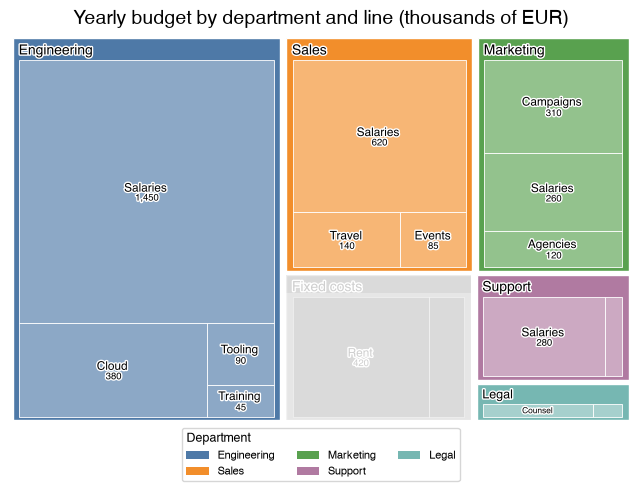

In [21]:
budget = {
    "data": [
        {
            "label": department,
            # the fixed costs are context, not a lever
            **({"emphasis": EMPHASIS.BACKGROUND} if department == "Fixed costs" else {}),
            "children": [{"label": line, "value": k} for line, k in lines],
        }
        for department, lines in BUDGET.items()
    ]
}

Treemap(
    data=budget,
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    show_legend=True,
    legend={"title": "Department", "location": LEGEND_LOCATION.OUTSIDE_BOTTOM, "ncols": 3},
    title="Yearly budget by department and line (thousands of EUR)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: How Has the World's Population Shifted? (Shares Across Years, a Rule, and a Grid)

In 1950 one person in five lived in Europe; today it is fewer than one in ten, while Africa's share has doubled. `WORLD_1950` holds the continent populations in 1950, in millions, from the same UN *World Population Prospects 2024* estimates (approximate, rounded), and the 2024 totals come from the shared dataset. Two flat treemaps show each year's shares as percentages, each filling its own cell, and `emphasis_rule={"top": 2}` keeps the eye on the two largest continents of each year. The palette follows the size order, so the orange tile is the runner-up in each year: Europe in 1950, Africa in 2024. A bar chart below gives the growth factor from 1950 to 2024, which says why the shares moved: Africa's population grew more than sixfold, Europe's by little more than a third. [Grid](../../utility/grid/) puts the two treemaps in the top row and the bar chart across the bottom.

In [22]:
# World population in 1950 by continent, millions (UN World Population
# Prospects 2024, approximate, rounded)
WORLD_1950 = {
    "Asia": 1380,
    "Africa": 230,
    "Europe": 550,
    "Latin America": 170,
    "Northern America": 160,
    "Oceania": 13,
}
WORLD_2024 = {r["label"]: r["value"] for r in continents["data"]}

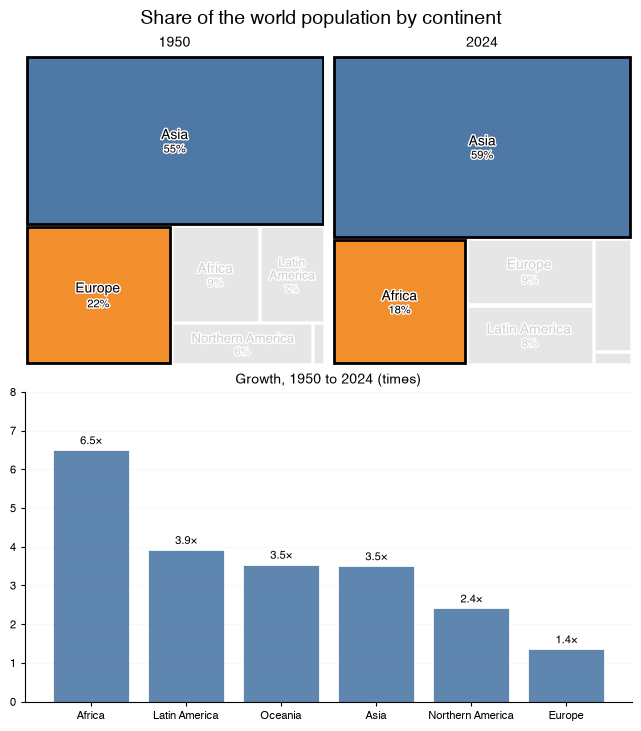

In [23]:
def share_map(year, populations):
    # a flat treemap of the continents' shares, the two largest highlighted
    whole = sum(populations.values())
    return Treemap(
        data={"data": [{"label": c, "value": n / whole} for c, n in populations.items()]},
        show_values=True,
        value_format=VALUE_FORMAT.PERCENT_INT,
        emphasis_rule={"top": 2},
        title=str(year),
    )


growth = BarChart(
    data=[{"label": c, "y": WORLD_2024[c] / WORLD_1950[c]} for c in WORLD_1950],
    title="Growth, 1950 to 2024 (times)",
    sort=SORT.DESCENDING,
    show_values=True,
    value_format="{x:.1f}×",
    show_grid=SHOW_GRID.Y,
    ymin=0,
    ymax=8,
)

Grid(
    [[share_map(1950, WORLD_1950), share_map(2024, WORLD_2024)], [growth]],
    title="Share of the world population by continent",
    figsize=FIG_SIZE.FULL_TALL,
).show()